In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,median_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi']=110
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)


In [3]:
data=pd.read_excel('ENB2012_data.xlsx')
data.head(5)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


Remove Quantitative Variables - Because X6 and X8 are just labels. There is no numerical values for them.

In [32]:
df_clean=(
    data
    .drop(columns=['X6','X8','Y2'])
    .dropna()
    .reset_index(drop=True)
)

In [33]:
df_clean.head()


,X1,X2,X3,X4,X5,X7,Y1
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84


In [7]:
TARGET ='Y1'

QUANTITATIVE_CANDIDATES =[
 'X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X7']

In [34]:
df_clean.describe()

,X1,X2,X3,X4,X5,X7,Y1
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,0.234375,22.307195
std,0.105777,88.086116,43.626481,45.165950,1.75114,0.133221,10.090204
min,0.620000,514.500000,245.000000,110.250000,3.50000,0.000000,6.010000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,0.100000,12.992500
50%,0.750000,673.750000,318.500000,183.750000,5.25000,0.250000,18.950000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,0.400000,31.667500
max,0.980000,808.500000,416.500000,220.500000,7.00000,0.400000,43.100000


In [35]:

x_attributes=QUANTITATIVE_CANDIDATES
cols=QUANTITATIVE_CANDIDATES+[TARGET]
cols

['X1', 'X2', 'X3', 'X4', 'X5', 'X7', 'Y1']

Univariate Analysis

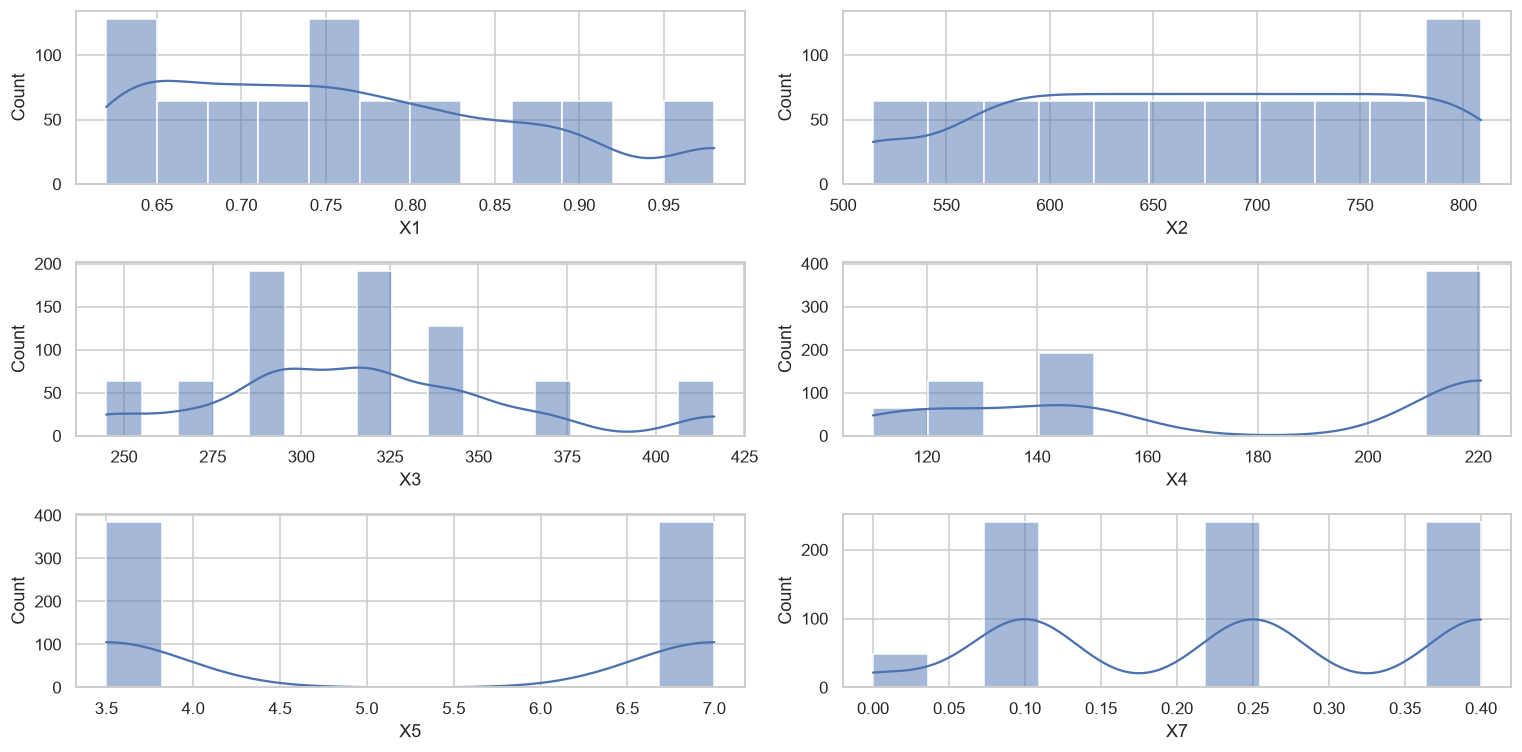

In [36]:
fig,axis=plt.subplots(3,2, figsize=(14,7))
axis=axis.ravel()

for i,c in enumerate(x_attributes):
    sns.histplot(df_clean[c],ax=axis[i],kde=True)
plt.tight_layout()
plt.show()

The distributions of the attributes do not appear to follow a clear normal distribution.

None of these predictors are smoothly and continuously spread out. Each one clusters into a small number of distinct groups with real gaps between them.Confirming there isn't a wide variety of values, just a limited set of repeated values.

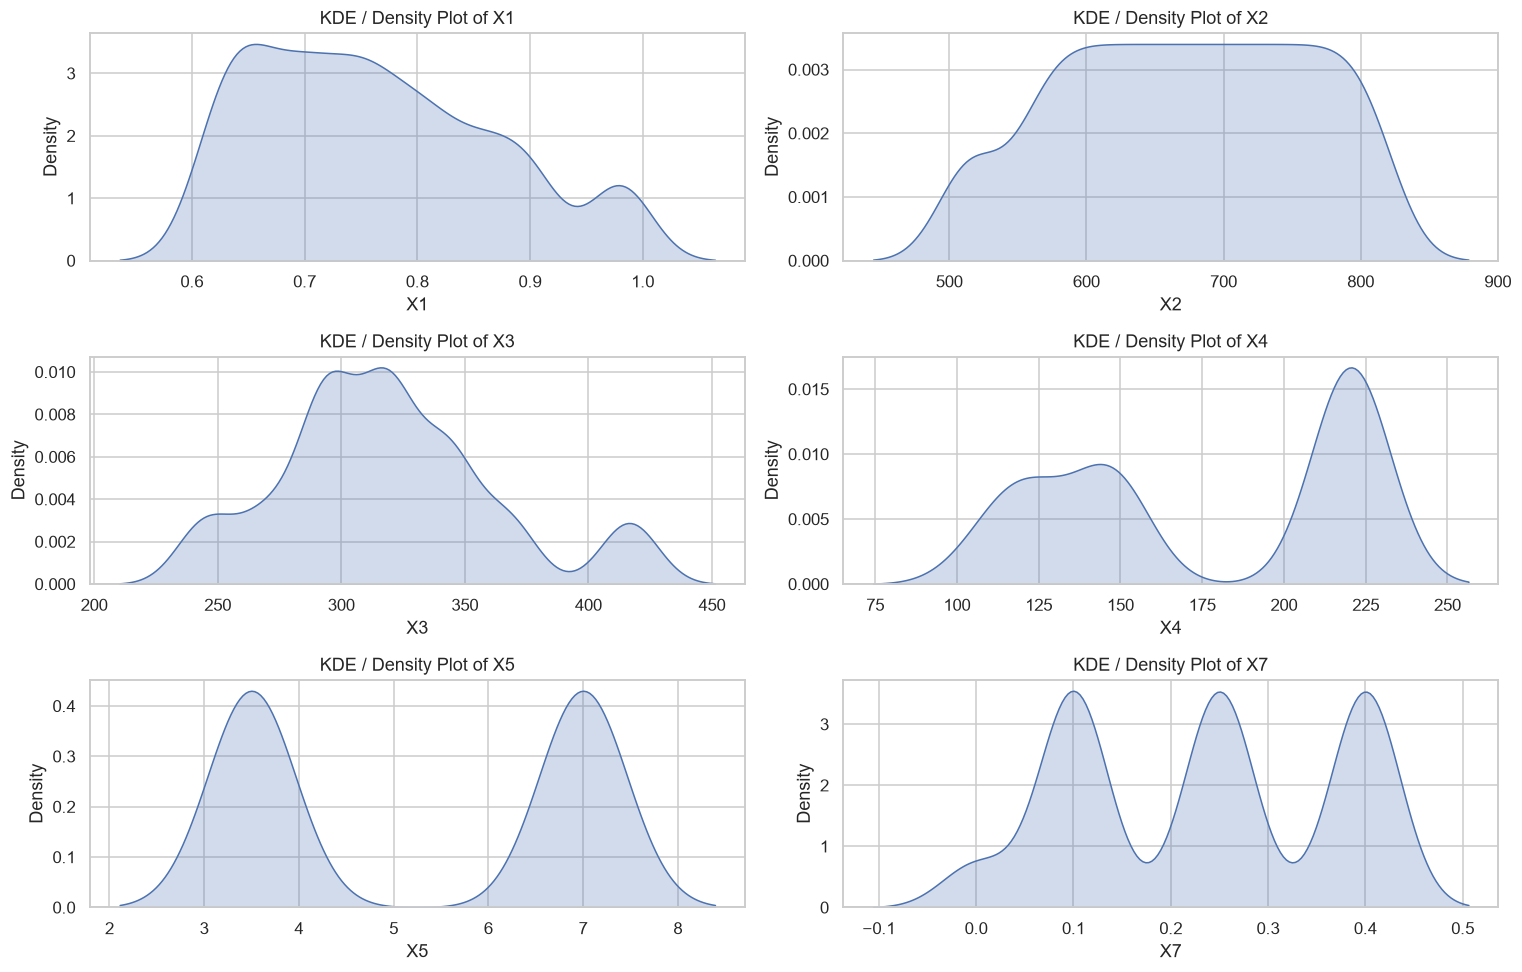

In [60]:
fig, axis = plt.subplots(3, 2, figsize=(14, 9))

axis = axis.ravel()

for i, c in enumerate(x_attributes):
    sns.kdeplot(data=df_clean, x=c, ax=axis[i], fill=True)
    axis[i].set_title(f"KDE / Density Plot of {c}")
    axis[i].set_xlabel(c)
    axis[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

Insights from KDE/Density Plots

X4 and X5: two separate bumps with a gap in the middle meaning buildings in this dataset only really come in two heights (and two roof-area sizes), nothing in between.

X7: three (almost four) evenly-sized bumps  the glazing area only comes in a few fixed settings, like options on a menu, not a smooth range of values.

X1: mostly one big bump, with a small second bump near the high end  a few extra compact buildings show up as their own little group.

X2, X3: pretty flat and spread out, no strong single peak.

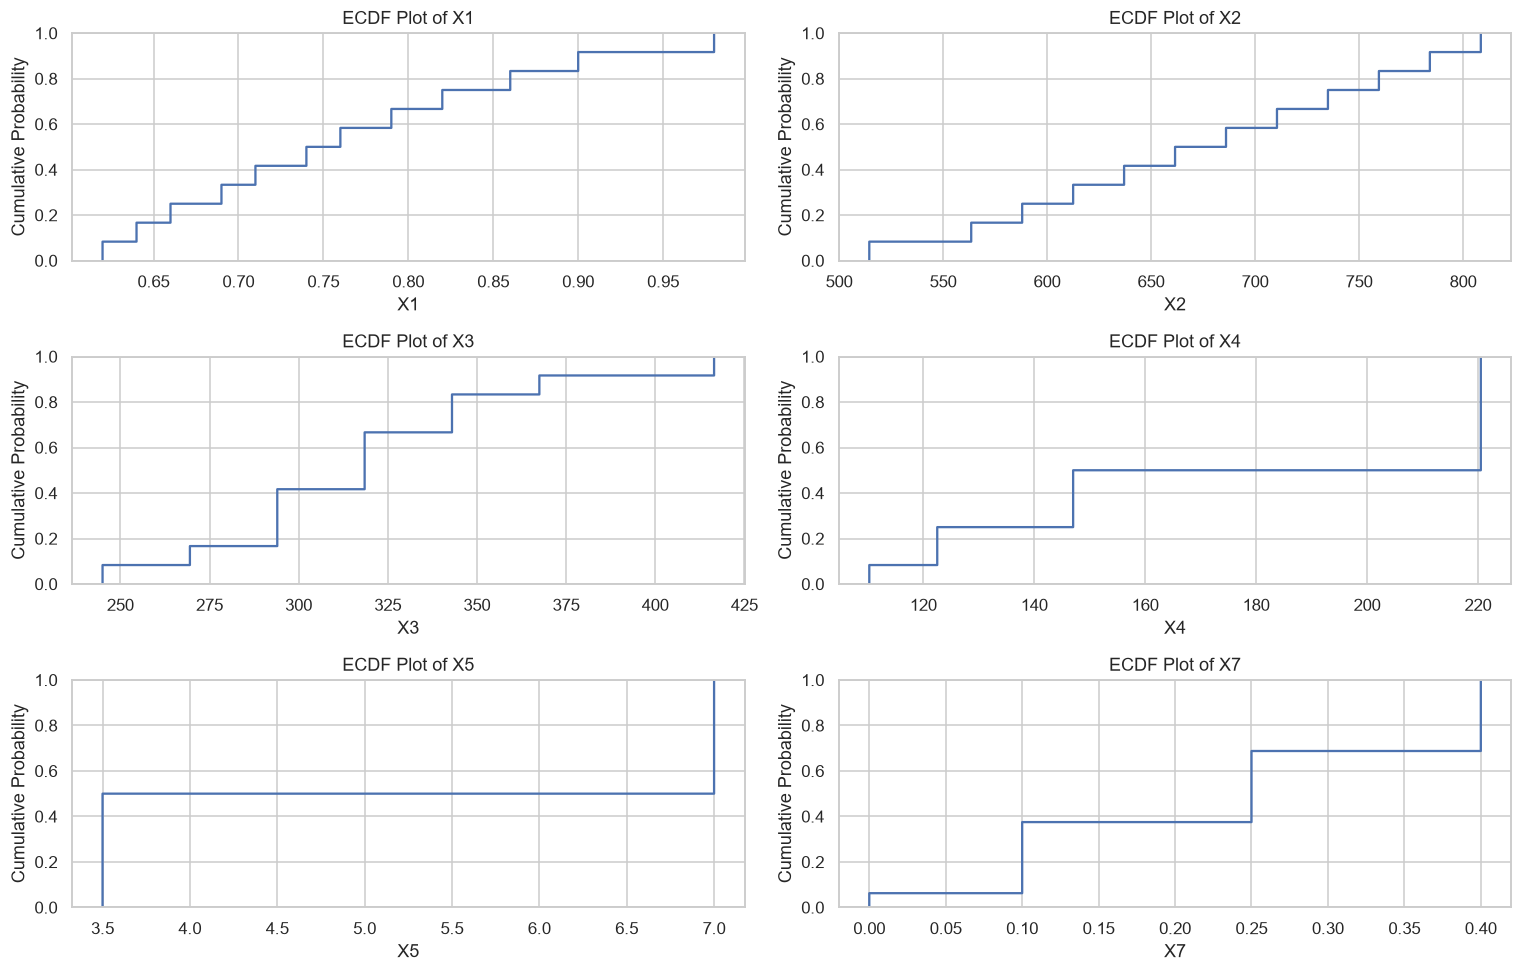

In [59]:
fig, axis = plt.subplots(3, 2, figsize=(14, 9))

axis = axis.ravel()

for i, c in enumerate(x_attributes):
    sns.ecdfplot(data=df_clean, x=c, ax=axis[i])
    axis[i].set_title(f"ECDF Plot of {c}")
    axis[i].set_xlabel(c)
    axis[i].set_ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

The KDE and ECDF plots show sharp bumps and blocky steps instead of smooth curves. This means the predictors don't vary freely across a wide range. They repeat a small set of fixed values across the dataset.

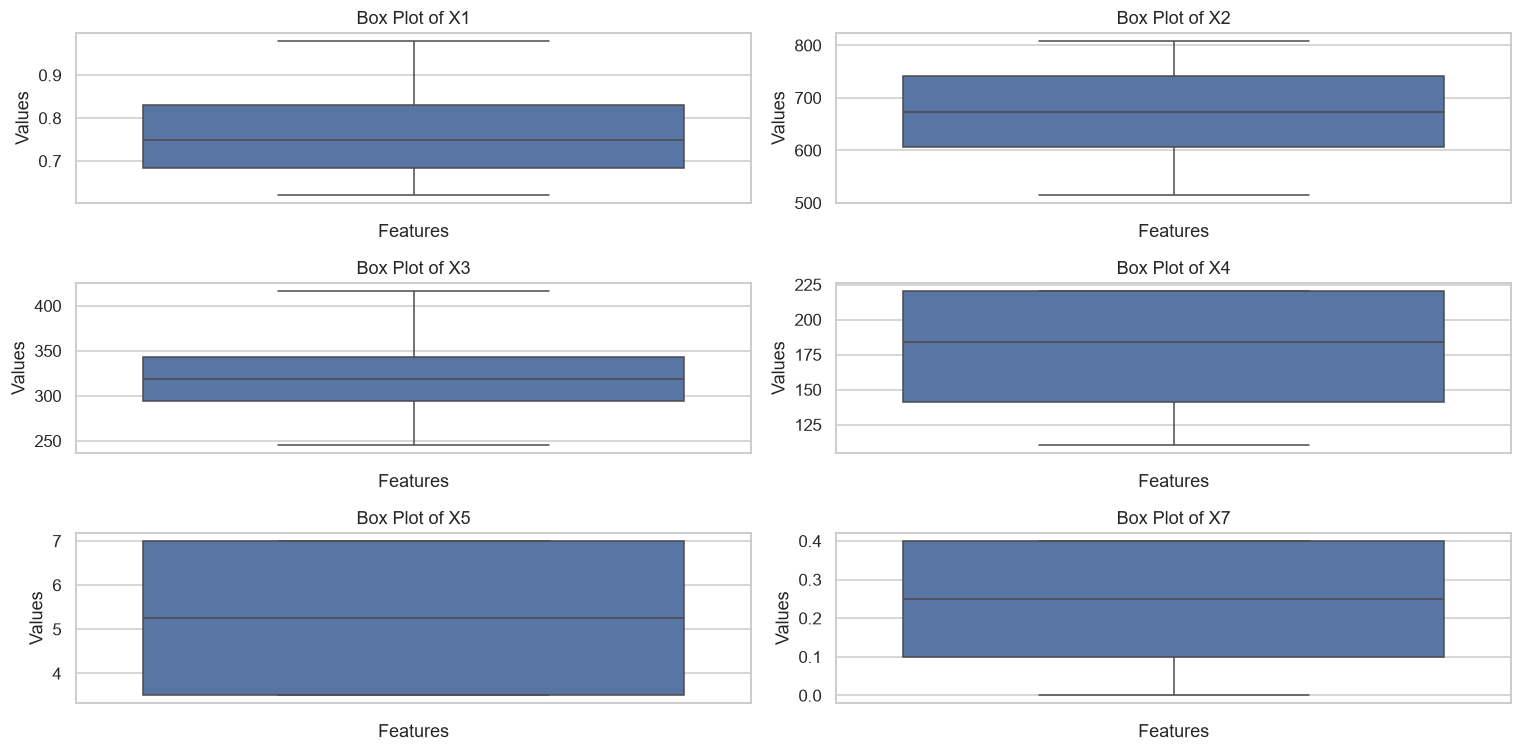

In [37]:
fig,axis=plt.subplots(3,2, figsize=(14,7))
axis=axis.ravel()

for i,c in enumerate(x_attributes):
    sns.boxplot(data=df_clean[c],ax=axis[i])
    axis[i].set_title(f"Box Plot of {c}")
    axis[i].set_xlabel("Features")
    axis[i].set_ylabel("Values")
plt.tight_layout()
plt.show()

The analysis indicates that there are no significant or visible outliers in any of the attributes.

Bi-variate Analysis

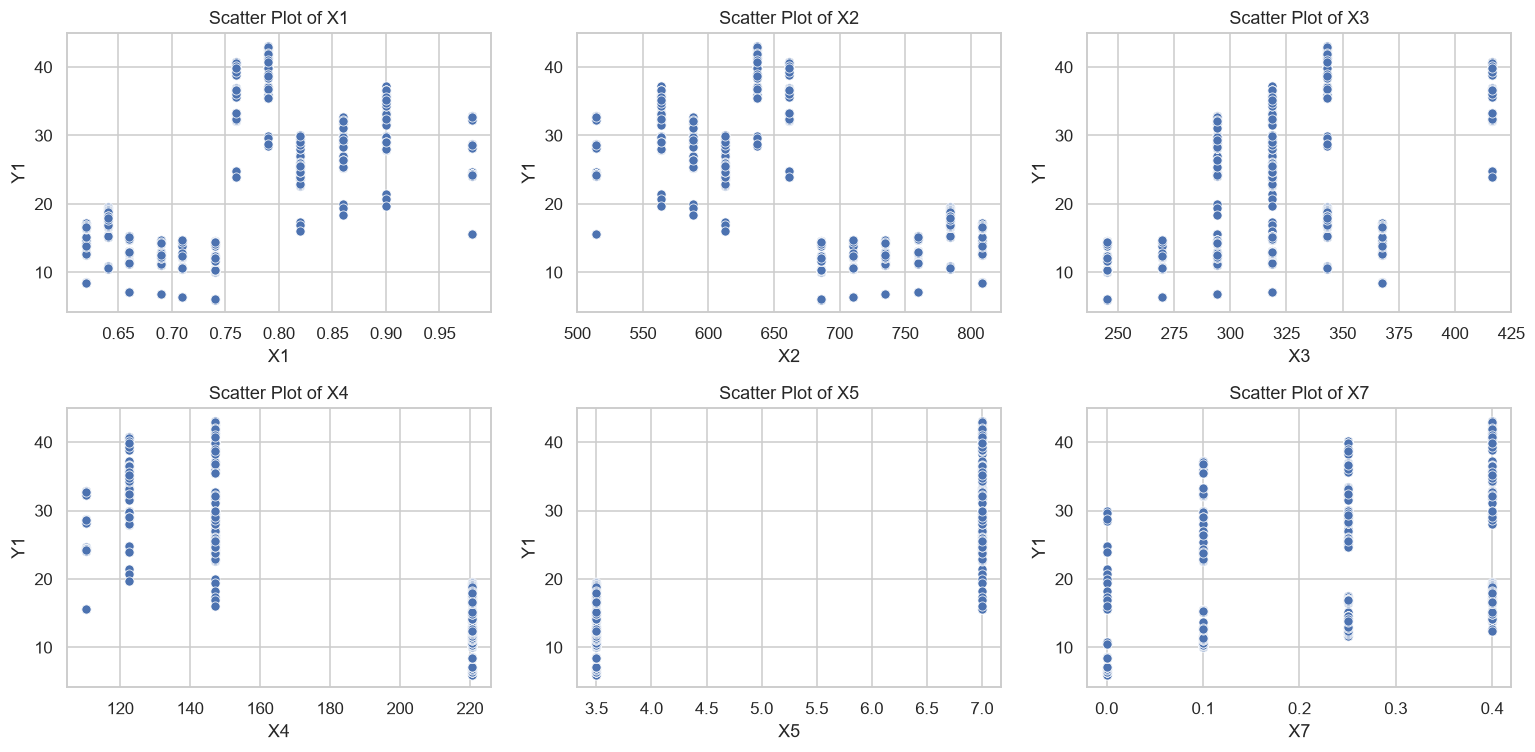

In [38]:
fig,axis=plt.subplots(2,3, figsize=(14,7))
axis=axis.ravel()


for i,c in enumerate(x_attributes):
    sns.scatterplot(data=df_clean,x=c,y=TARGET,ax=axis[i])
    axis[i].set_title(f"Scatter Plot of {c}")
    axis[i].set_xlabel(c)
    axis[i].set_ylabel(TARGET)
plt.tight_layout()
plt.show()

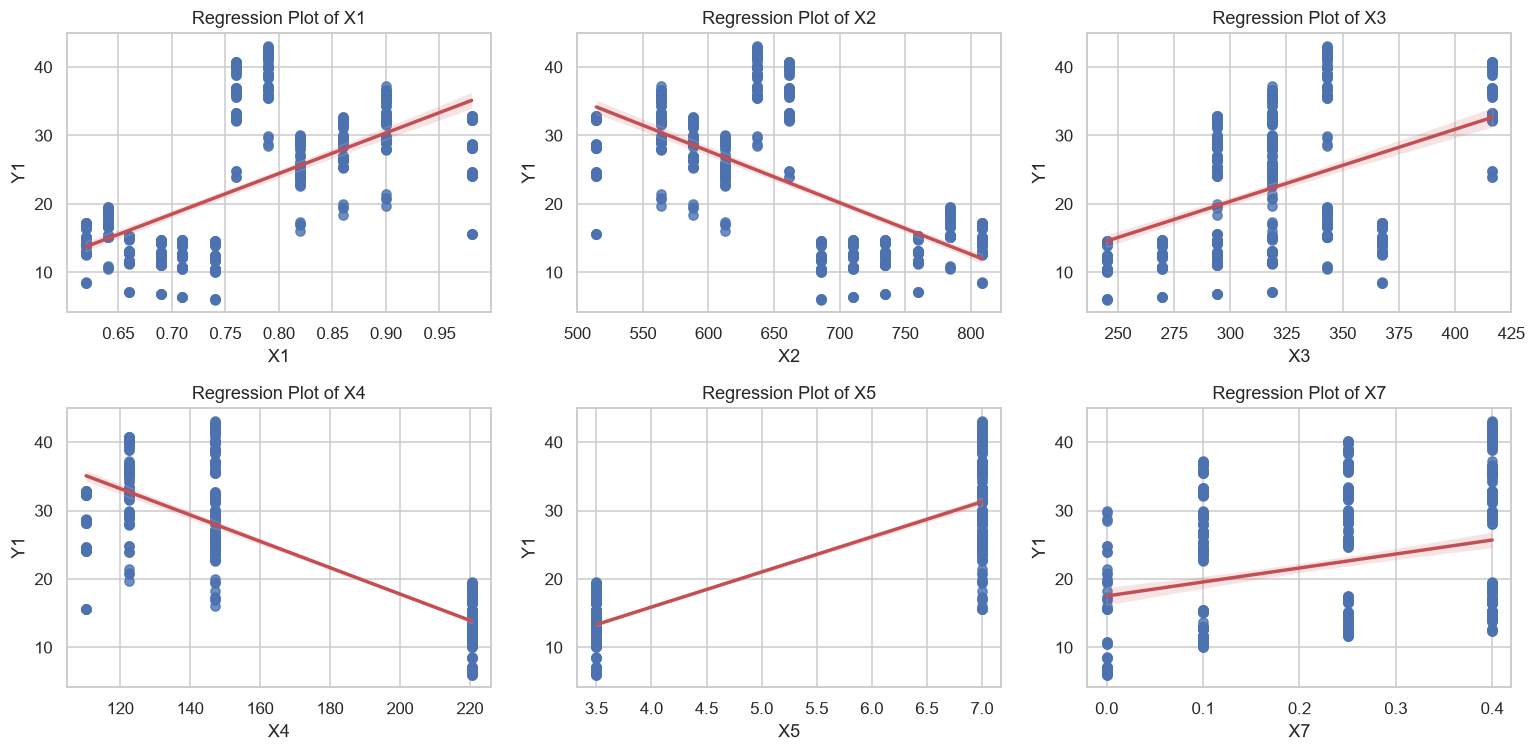

In [39]:
fig,axis=plt.subplots(2,3, figsize=(14,7))
axis=axis.ravel()


for i,c in enumerate(x_attributes):
    sns.regplot(data=df_clean,x=c,y=TARGET,ax=axis[i],line_kws=dict(color="r"))
    axis[i].set_title(f"Regression Plot of {c}")
    axis[i].set_xlabel(c)
    axis[i].set_ylabel(TARGET)
plt.tight_layout()
plt.show()

Based on the regression plots and scatter plots, there is no strong or clearly visible linear relationship between the target variable (Heating Load) and each individual predictor variable.

Correlation Analysis

In [40]:
df_clean.corr()

,X1,X2,X3,X4,X5,X7,Y1
X1,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,-2.960552e-15,0.622272
X2,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,3.636925e-15,-0.658120
X3,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-8.567455e-17,0.455671
X4,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-1.759011e-15,-0.861828
X5,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,1.489134e-17,0.889430
X7,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,1.000000e+00,0.269842
Y1,6.222719e-01,-6.581199e-01,4.556714e-01,-8.618281e-01,8.894305e-01,2.698417e-01,1.000000


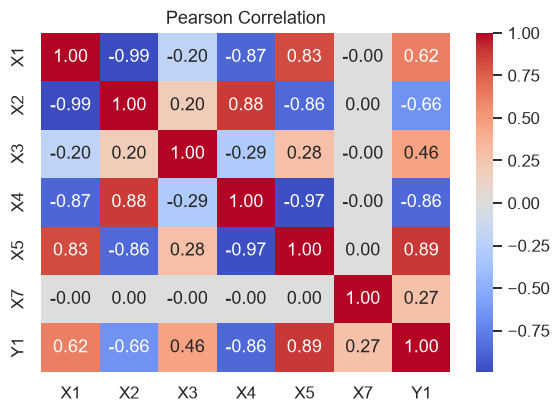

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(df_clean.corr(),annot=True,fmt=".2f",cmap="coolwarm",cbar=True)
plt.title("Pearson Correlation")
plt.show()

Correlation Analysis

Strong positive correlation with Heating Load (Y1)
    X5 (Overall Height) → 0.889

    As overall height increases, Heating Load tends to increase.

Strong negative correlation with Heating Load (Y1)
    X4 (Roof Area) → -0.862


     As Roof Area increases, Heating Load tends to decrease.

Multicollinearity

X1 and X2: -0.992 — extremely strong negative correlation
X4 and X5: -0.973 — extremely strong negative correlation
X2 and X4: 0.881 — strong positive correlation
X2 and X5: -0.858 — strong negative correlation
X1 and X5: 0.828 — strong positive correlation


As a result, multicollinearity may affect the stability and interpretation of the regression coefficients, making it difficult to determine the individual contribution of each predictor to Heating Load.

Findings

Relationships between predictors and Target variable (Y1)

    X5 (Overall Height) has the strongest relationship (correlation) of 0.89 with Y1. Taller buildings has higher heating load.

    X4 (Roof Area) is nearly as strong but negative correlation of -0.86.Larger roof area has lower heating load.


Skewness and Outliers

    No boxplot  shows any points beyond the whiskers.No outliers in any of the six quantitative predictors.

    X1,X2 and X3 are unimodal distribution with right skewed. (Slight positive skew)

    X4,X5 and X6 are multi modal distribution.


In [61]:
X=df_clean[QUANTITATIVE_CANDIDATES].values
Y=df_clean[TARGET].values


In [51]:
train_size=0.75
test_size=0.25

x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=train_size,test_size=test_size,random_state=42)

In [70]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-64.91, -0.06, 0.04, -0.05, 4.01, 20.21]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,86.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[2332.26,1119.46, 9.81, 3.2 , 0.25, 0. ]"


In [71]:
# Train-set predictions and metrics
y_train_pred = model.predict(x_train)

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

In [72]:
train_r2

0.9150341567317789

In [73]:
train_rmse

2.920239272854163

In [74]:
train_mae

2.0236003486230625

In [63]:
y_pred=model.predict(x_test)

In [66]:
eval_rmse=root_mean_squared_error(y_pred=y_pred,y_true=y_test)

eval_rmse

2.989396828152499

In [67]:
eval_mae= mean_absolute_error(y_pred=y_pred,y_true=y_test)

eval_mae

2.147063466879538

In [69]:
eval_r2=r2_score(y_pred=y_pred,y_true=y_test)

eval_r2

0.9149801212043022

In [75]:
print(f"Train R²:   {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE:  {train_mae:.4f}")

print(f"\nTest R²:    {eval_r2:.4f}")
print(f"Test RMSE:  {eval_rmse:.4f}")
print(f"Test MAE:   {eval_mae:.4f}")

print(f"\nR² gap (train - test):   {train_r2 - eval_r2:.4f}")
print(f"RMSE gap (test - train): {eval_rmse - train_rmse:.4f}")

Train R²:   0.9150
Train RMSE: 2.9202
Train MAE:  2.0236

Test R²:    0.9150
Test RMSE:  2.9894
Test MAE:   2.1471

R² gap (train - test):   0.0001
RMSE gap (test - train): 0.0692
